<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/v-kernel/blob/main/notebooks/diffusion_transaction_log.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

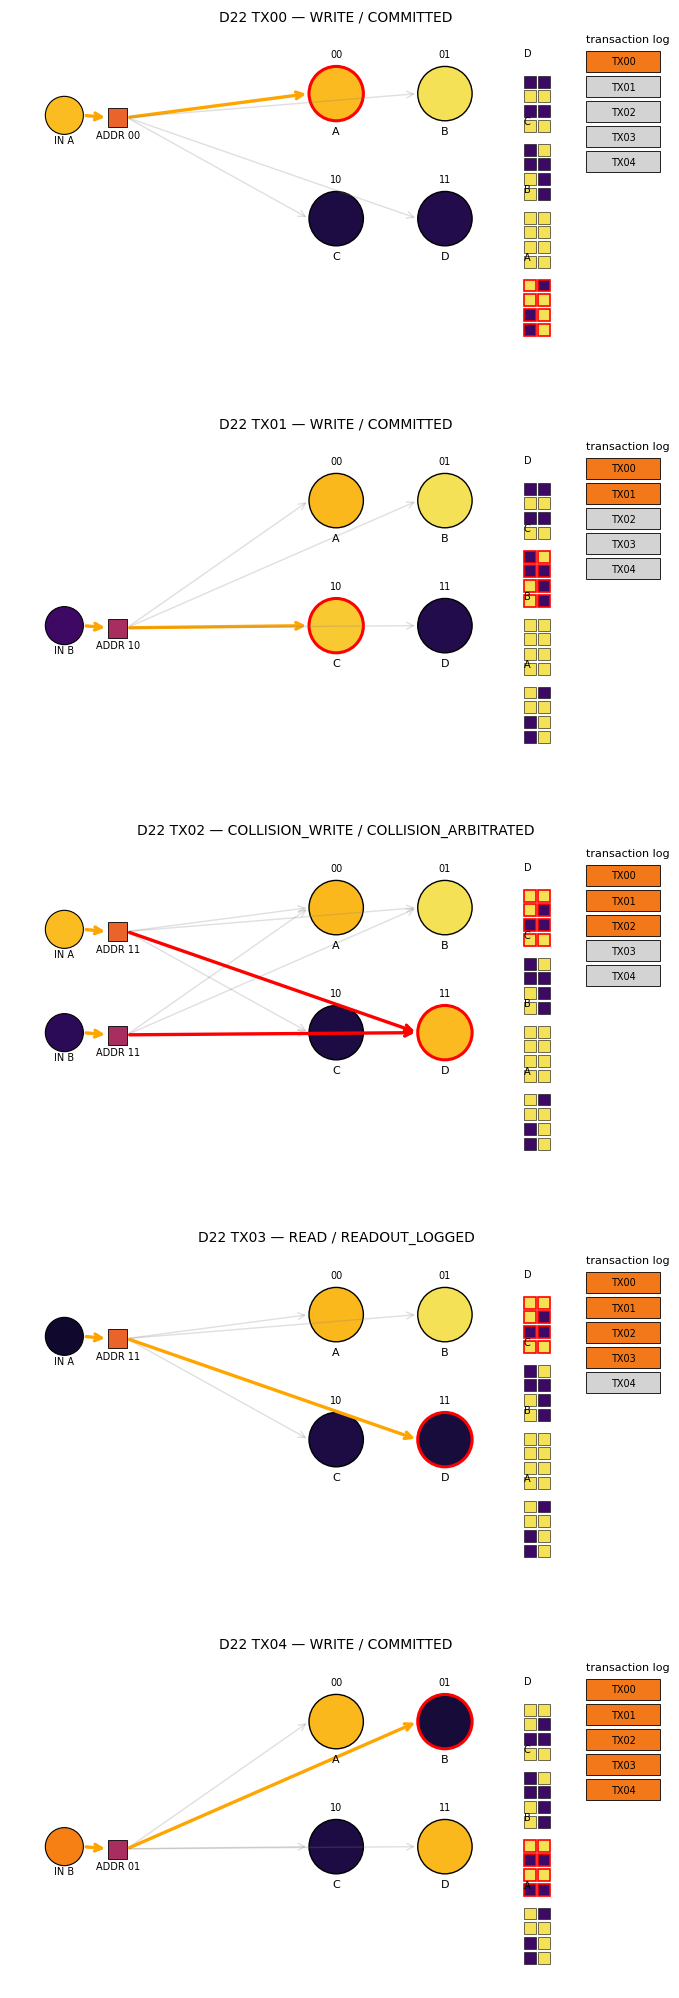

STATE: TRANSACTION_LOG_LOCKED
transactions:       5
committed writes:   4
conflicts logged:   1
reads logged:       1
replay accuracy:    1.0
journal integrity:  1.0
final log hash:     4eb75ac7954a

Address decode table:


,STATE,TX_ID,SOURCE,ADDRESS_BIT_INDEX,INPUT_ADDRESS_BIT,RECEIVED_MEAN,DECODED_ADDRESS_BIT,MATCH
0,D22_TRANSACTION_LOG,TX00,A,0,0,0.218,0,1
1,D22_TRANSACTION_LOG,TX00,A,1,0,0.183,0,1
2,D22_TRANSACTION_LOG,TX01,B,0,1,0.787,1,1
3,D22_TRANSACTION_LOG,TX01,B,1,0,0.214,0,1
4,D22_TRANSACTION_LOG,TX02,A,0,1,0.748,1,1
5,D22_TRANSACTION_LOG,TX02,A,1,1,0.735,1,1
6,D22_TRANSACTION_LOG,TX02,B,0,1,0.783,1,1
7,D22_TRANSACTION_LOG,TX02,B,1,1,0.732,1,1
8,D22_TRANSACTION_LOG,TX03,A,0,1,0.776,1,1
9,D22_TRANSACTION_LOG,TX03,A,1,1,0.746,1,1



Transaction log:


,STATE,TX_INDEX,TX_ID,OP,WRITER,ADDR_A,ADDR_B,DECODED_ADDR_A,DECODED_ADDR_B,SELECTED_CELL,WINNER,BEFORE_SEQUENCE,PAYLOAD_WRITTEN,AFTER_SEQUENCE,READOUT_SEQUENCE,RESULT,PREV_HASH,TX_HASH
0,D22_TRANSACTION_LOG,0,TX00,WRITE,A,00,,00,,MEM_CELL_A,A,00000000,10110101,10110101,10110101,COMMITTED,GENESIS0000,aab8cd7560cf
1,D22_TRANSACTION_LOG,1,TX01,WRITE,B,,10,,10,MEM_CELL_C,B,01001010,01001010,01001010,01001010,COMMITTED,aab8cd7560cf,3ad758d43ea3
2,D22_TRANSACTION_LOG,2,TX02,COLLISION_WRITE,A+B,11,11,11,11,MEM_CELL_D,A,00110011,11100011,11100011,11100011,COLLISION_ARBITRATED,3ad758d43ea3,fef6bc7ff7a3
3,D22_TRANSACTION_LOG,3,TX03,READ,R,11,,11,,MEM_CELL_D,R,11100011,,11100011,11100011,READOUT_LOGGED,fef6bc7ff7a3,91a330a3880d
4,D22_TRANSACTION_LOG,4,TX04,WRITE,B,,01,,01,MEM_CELL_B,B,11111111,11001100,11001100,11001100,COMMITTED,91a330a3880d,4eb75ac7954a



Replay table:


,STATE,CELL,INITIAL_SEQUENCE,LIVE_FINAL_SEQUENCE,REPLAY_FINAL_SEQUENCE,REPLAY_ACCURACY,MATCH
0,D22_TRANSACTION_LOG,MEM_CELL_A,00000000,10110101,10110101,1.0,1
1,D22_TRANSACTION_LOG,MEM_CELL_B,11111111,11001100,11001100,1.0,1
2,D22_TRANSACTION_LOG,MEM_CELL_C,01001010,01001010,01001010,1.0,1
3,D22_TRANSACTION_LOG,MEM_CELL_D,00110011,11100011,11100011,1.0,1



Hash-chain integrity table:


,STATE,TX_ID,EXPECTED_PREV_HASH,LOG_PREV_HASH,EXPECTED_TX_HASH,LOG_TX_HASH,HASH_OK
0,D22_TRANSACTION_LOG,TX00,GENESIS0000,GENESIS0000,aab8cd7560cf,aab8cd7560cf,1
1,D22_TRANSACTION_LOG,TX01,aab8cd7560cf,aab8cd7560cf,3ad758d43ea3,3ad758d43ea3,1
2,D22_TRANSACTION_LOG,TX02,3ad758d43ea3,3ad758d43ea3,fef6bc7ff7a3,fef6bc7ff7a3,1
3,D22_TRANSACTION_LOG,TX03,fef6bc7ff7a3,fef6bc7ff7a3,91a330a3880d,91a330a3880d,1
4,D22_TRANSACTION_LOG,TX04,91a330a3880d,91a330a3880d,4eb75ac7954a,4eb75ac7954a,1



Summary:


,STATE,RESULT,TRANSACTIONS,COMMITTED_WRITES,CONFLICTS_LOGGED,READS_LOGGED,REPLAY_ACCURACY,JOURNAL_INTEGRITY,FINAL_HASH
0,D22_TRANSACTION_LOG,TRANSACTION_LOG_LOCKED,5,4,1,1,1.0,1.0,4eb75ac7954a


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import hashlib
from matplotlib.patches import Circle, Rectangle, FancyArrowPatch

# ============================================================
# D22_TRANSACTION_LOG
# Field memory transaction journal
#
# Goal:
# routed memory writes
# -> transaction log
# -> conflict record
# -> readout record
# -> replay from log
# -> verify final memory and log integrity
# ============================================================

np.random.seed(22)

STATE = "D22_TRANSACTION_LOG"
decode_threshold = 0.50

address_map = {
    "00": "MEM_CELL_A",
    "01": "MEM_CELL_B",
    "10": "MEM_CELL_C",
    "11": "MEM_CELL_D",
}

memory_initial = {
    "MEM_CELL_A": "00000000",
    "MEM_CELL_B": "11111111",
    "MEM_CELL_C": "01001010",
    "MEM_CELL_D": "00110011",
}

transactions = [
    {
        "TX_ID": "TX00",
        "OP": "WRITE",
        "WRITER": "A",
        "ADDR_A": "00",
        "PAYLOAD_A": "10110101",
    },
    {
        "TX_ID": "TX01",
        "OP": "WRITE",
        "WRITER": "B",
        "ADDR_B": "10",
        "PAYLOAD_B": "01001010",
    },
    {
        "TX_ID": "TX02",
        "OP": "COLLISION_WRITE",
        "WRITER": "A+B",
        "ADDR_A": "11",
        "ADDR_B": "11",
        "PAYLOAD_A": "11100011",
        "PAYLOAD_B": "00011100",
        "PRIORITY": "A",
    },
    {
        "TX_ID": "TX03",
        "OP": "READ",
        "WRITER": "R",
        "ADDR_A": "11",
    },
    {
        "TX_ID": "TX04",
        "OP": "WRITE",
        "WRITER": "B",
        "ADDR_B": "01",
        "PAYLOAD_B": "11001100",
    },
]


def seq_to_bits(seq):
    return [int(x) for x in seq]


def bits_to_string(bits):
    return "".join(str(int(x)) for x in bits)


def accuracy(a, b):
    return float(np.mean(np.array(seq_to_bits(a)) == np.array(seq_to_bits(b))))


def decode_address(addr):
    if addr is None:
        return "", []

    received = []
    decoded = []

    for bit in addr:
        if bit == "1":
            value = 0.76 + np.random.normal(0, 0.025)
        else:
            value = 0.22 + np.random.normal(0, 0.025)

        value = float(np.clip(value, 0.0, 1.0))
        received.append(value)
        decoded.append(1 if value >= decode_threshold else 0)

    return bits_to_string(decoded), received


def stable_hash(*parts):
    text = "|".join(str(x) for x in parts)
    return hashlib.sha256(text.encode("utf-8")).hexdigest()[:12]


def make_tx_hash(
    prev_hash,
    tx_id,
    op,
    decoded_a,
    decoded_b,
    selected_cell,
    winner,
    before,
    written,
    after,
    readout,
    result,
):
    return stable_hash(
        prev_hash,
        tx_id,
        op,
        decoded_a,
        decoded_b,
        selected_cell,
        winner,
        before,
        written,
        after,
        readout,
        result,
    )


# ------------------------------------------------------------
# Live execution with transaction logging
# ------------------------------------------------------------

memory_live = memory_initial.copy()
log_rows = []
route_rows = []

prev_hash = "GENESIS0000"

for tx_index, tx in enumerate(transactions):
    tx_id = tx["TX_ID"]
    op = tx["OP"]

    addr_a = tx.get("ADDR_A")
    addr_b = tx.get("ADDR_B")

    decoded_a, received_a = decode_address(addr_a)
    decoded_b, received_b = decode_address(addr_b)

    for source, addr, decoded, received in [
        ("A", addr_a, decoded_a, received_a),
        ("B", addr_b, decoded_b, received_b),
    ]:
        if addr is None:
            continue

        for bit_index, bit in enumerate(addr):
            route_rows.append({
                "STATE": STATE,
                "TX_ID": tx_id,
                "SOURCE": source,
                "ADDRESS_BIT_INDEX": bit_index,
                "INPUT_ADDRESS_BIT": int(bit),
                "RECEIVED_MEAN": round(received[bit_index], 3),
                "DECODED_ADDRESS_BIT": int(decoded[bit_index]),
                "MATCH": int(decoded[bit_index] == bit),
            })

    selected_cell = ""
    winner = ""
    before = ""
    payload_written = ""
    after = ""
    readout = ""
    result = "NO_OP"

    if op == "WRITE":
        if tx["WRITER"] == "A":
            selected_cell = address_map[decoded_a]
            payload_written = tx["PAYLOAD_A"]
            winner = "A"
        else:
            selected_cell = address_map[decoded_b]
            payload_written = tx["PAYLOAD_B"]
            winner = "B"

        before = memory_live[selected_cell]
        memory_live[selected_cell] = payload_written
        after = memory_live[selected_cell]
        readout = after
        result = "COMMITTED"

    elif op == "COLLISION_WRITE":
        cell_a = address_map[decoded_a]
        cell_b = address_map[decoded_b]

        same_address = cell_a == cell_b
        same_payload = tx["PAYLOAD_A"] == tx["PAYLOAD_B"]

        if same_address and same_payload:
            selected_cell = cell_a
            winner = "A+B"
            payload_written = tx["PAYLOAD_A"]
            before = memory_live[cell_a]
            memory_live[cell_a] = payload_written
            after = memory_live[cell_a]
            readout = after
            result = "SAFE_DUPLICATE"

        elif same_address and not same_payload:
            selected_cell = cell_a
            winner = tx.get("PRIORITY", "A")
            payload_written = tx["PAYLOAD_A"] if winner == "A" else tx["PAYLOAD_B"]
            before = memory_live[cell_a]
            memory_live[cell_a] = payload_written
            after = memory_live[cell_a]
            readout = after
            result = "COLLISION_ARBITRATED"

        else:
            selected_cell = f"{cell_a}+{cell_b}"
            winner = "A+B"
            before = f"{memory_live[cell_a]}/{memory_live[cell_b]}"
            memory_live[cell_a] = tx["PAYLOAD_A"]
            memory_live[cell_b] = tx["PAYLOAD_B"]
            payload_written = f"{tx['PAYLOAD_A']}/{tx['PAYLOAD_B']}"
            after = f"{memory_live[cell_a]}/{memory_live[cell_b]}"
            readout = after
            result = "PARALLEL_COMMIT"

    elif op == "READ":
        selected_cell = address_map[decoded_a]
        before = memory_live[selected_cell]
        after = before
        readout = before
        winner = "R"
        result = "READOUT_LOGGED"

    tx_hash = make_tx_hash(
        prev_hash,
        tx_id,
        op,
        decoded_a,
        decoded_b,
        selected_cell,
        winner,
        before,
        payload_written,
        after,
        readout,
        result,
    )

    log_rows.append({
        "STATE": STATE,
        "TX_INDEX": tx_index,
        "TX_ID": tx_id,
        "OP": op,
        "WRITER": tx["WRITER"],
        "ADDR_A": addr_a or "",
        "ADDR_B": addr_b or "",
        "DECODED_ADDR_A": decoded_a,
        "DECODED_ADDR_B": decoded_b,
        "SELECTED_CELL": selected_cell,
        "WINNER": winner,
        "BEFORE_SEQUENCE": before,
        "PAYLOAD_WRITTEN": payload_written,
        "AFTER_SEQUENCE": after,
        "READOUT_SEQUENCE": readout,
        "RESULT": result,
        "PREV_HASH": prev_hash,
        "TX_HASH": tx_hash,
    })

    prev_hash = tx_hash


df_route = pd.DataFrame(route_rows)
df_log = pd.DataFrame(log_rows)


# ------------------------------------------------------------
# Replay final memory from transaction log
# ------------------------------------------------------------

memory_replay = memory_initial.copy()

for _, row in df_log.iterrows():
    if row["RESULT"] in ["COMMITTED", "SAFE_DUPLICATE", "COLLISION_ARBITRATED"]:
        memory_replay[row["SELECTED_CELL"]] = row["PAYLOAD_WRITTEN"]

    elif row["RESULT"] == "PARALLEL_COMMIT":
        cell_a, cell_b = row["SELECTED_CELL"].split("+")
        payload_a, payload_b = row["PAYLOAD_WRITTEN"].split("/")
        memory_replay[cell_a] = payload_a
        memory_replay[cell_b] = payload_b


replay_rows = []

for cell in memory_initial:
    live = memory_live[cell]
    replay = memory_replay[cell]

    replay_rows.append({
        "STATE": STATE,
        "CELL": cell,
        "INITIAL_SEQUENCE": memory_initial[cell],
        "LIVE_FINAL_SEQUENCE": live,
        "REPLAY_FINAL_SEQUENCE": replay,
        "REPLAY_ACCURACY": round(accuracy(live, replay), 3),
        "MATCH": int(live == replay),
    })

df_replay = pd.DataFrame(replay_rows)
replay_accuracy = float(df_replay["MATCH"].mean())


# ------------------------------------------------------------
# Verify hash-chain integrity
# ------------------------------------------------------------

verify_rows = []
current_hash = "GENESIS0000"

for _, row in df_log.iterrows():
    expected_hash = make_tx_hash(
        current_hash,
        row["TX_ID"],
        row["OP"],
        row["DECODED_ADDR_A"],
        row["DECODED_ADDR_B"],
        row["SELECTED_CELL"],
        row["WINNER"],
        row["BEFORE_SEQUENCE"],
        row["PAYLOAD_WRITTEN"],
        row["AFTER_SEQUENCE"],
        row["READOUT_SEQUENCE"],
        row["RESULT"],
    )

    ok = (expected_hash == row["TX_HASH"]) and (current_hash == row["PREV_HASH"])

    verify_rows.append({
        "STATE": STATE,
        "TX_ID": row["TX_ID"],
        "EXPECTED_PREV_HASH": current_hash,
        "LOG_PREV_HASH": row["PREV_HASH"],
        "EXPECTED_TX_HASH": expected_hash,
        "LOG_TX_HASH": row["TX_HASH"],
        "HASH_OK": int(ok),
    })

    current_hash = expected_hash

df_hash = pd.DataFrame(verify_rows)
journal_integrity = float(df_hash["HASH_OK"].mean())


committed_writes = int(
    df_log["RESULT"].isin([
        "COMMITTED",
        "SAFE_DUPLICATE",
        "COLLISION_ARBITRATED",
        "PARALLEL_COMMIT",
    ]).sum()
)

conflicts_logged = int((df_log["RESULT"] == "COLLISION_ARBITRATED").sum())
reads_logged = int((df_log["RESULT"] == "READOUT_LOGGED").sum())

final_result = (
    "TRANSACTION_LOG_LOCKED"
    if replay_accuracy == 1.0 and journal_integrity == 1.0
    else "TRANSACTION_LOG_PARTIAL"
)

df_summary = pd.DataFrame([{
    "STATE": STATE,
    "RESULT": final_result,
    "TRANSACTIONS": len(df_log),
    "COMMITTED_WRITES": committed_writes,
    "CONFLICTS_LOGGED": conflicts_logged,
    "READS_LOGGED": reads_logged,
    "REPLAY_ACCURACY": round(replay_accuracy, 3),
    "JOURNAL_INTEGRITY": round(journal_integrity, 3),
    "FINAL_HASH": prev_hash,
}])


# ------------------------------------------------------------
# Visualization
# ------------------------------------------------------------

def bit_color(bit, intensity=1.0):
    if bit == 1:
        return plt.cm.inferno(0.70 + 0.22 * intensity)
    return plt.cm.inferno(0.07 + 0.12 * intensity)


cell_positions = {
    "MEM_CELL_A": (6.0, 6.0),
    "MEM_CELL_B": (8.0, 6.0),
    "MEM_CELL_C": (6.0, 3.7),
    "MEM_CELL_D": (8.0, 3.7),
}

address_labels = {
    "MEM_CELL_A": "00",
    "MEM_CELL_B": "01",
    "MEM_CELL_C": "10",
    "MEM_CELL_D": "11",
}


def draw_bit_grid(ax, x0, y0, seq, title, selected=False):
    bits = seq_to_bits(seq)
    cell = 0.22
    gap = 0.05

    ax.text(x0, y0 + 1.35, title, fontsize=7, ha="left", va="bottom", color="black")

    for i, bit in enumerate(bits):
        col = i % 2
        row = i // 2

        x = x0 + col * (cell + gap)
        y = y0 + (3 - row) * (cell + gap)

        edge = "red" if selected else "black"
        lw = 1.2 if selected else 0.4

        rect = Rectangle(
            (x, y),
            cell,
            cell,
            facecolor=bit_color(bit),
            edgecolor=edge,
            linewidth=lw,
        )
        ax.add_patch(rect)


def draw_arrow(ax, start, end, active=False, conflict=False):
    color = "red" if conflict else "orange" if active else "gray"
    alpha = 1.0 if active or conflict else 0.25
    lw = 2.4 if active or conflict else 1.0

    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="->",
        mutation_scale=12,
        linewidth=lw,
        color=color,
        alpha=alpha,
    )
    ax.add_patch(arrow)


def draw_cell(ax, name, seq, selected=False, active=False, phase=0.0):
    x, y = cell_positions[name]
    bits = seq_to_bits(seq)

    mean_bit = float(np.mean(bits))
    pulse = 0.5 + 0.5 * np.sin(2 * np.pi * phase)
    visual_value = 0.35 * mean_bit + 0.65 * pulse if active else mean_bit

    color = bit_color(1 if visual_value > 0.5 else 0, visual_value)
    edge = "red" if selected else "black"
    lw = 2.2 if selected else 1.0

    ax.add_patch(Circle((x, y), 0.5, facecolor=color, edgecolor=edge, linewidth=lw))
    ax.text(x, y - 0.75, name[-1], fontsize=8, ha="center", color="black")
    ax.text(x, y + 0.68, address_labels[name], fontsize=7, ha="center", color="black")


def draw_log_chain(ax, x0, y0, upto_index):
    cell_h = 0.38
    gap = 0.08

    ax.text(x0, y0 + 0.55, "transaction log", fontsize=8, ha="left", color="black")

    for i in range(len(df_log)):
        y = y0 - i * (cell_h + gap)

        if i <= upto_index:
            color = plt.cm.inferno(0.70)
        else:
            color = "lightgray"

        rect = Rectangle(
            (x0, y),
            1.35,
            cell_h,
            facecolor=color,
            edgecolor="black",
            linewidth=0.6,
        )
        ax.add_patch(rect)

        tx_label = df_log.iloc[i]["TX_ID"]
        ax.text(
            x0 + 0.68,
            y + cell_h / 2,
            tx_label,
            fontsize=7,
            ha="center",
            va="center",
            color="black",
        )


def memory_after_tx(tx_limit):
    mem = memory_initial.copy()

    for i in range(tx_limit + 1):
        row = df_log.iloc[i]

        if row["RESULT"] in ["COMMITTED", "SAFE_DUPLICATE", "COLLISION_ARBITRATED"]:
            mem[row["SELECTED_CELL"]] = row["PAYLOAD_WRITTEN"]

        elif row["RESULT"] == "PARALLEL_COMMIT":
            cell_a, cell_b = row["SELECTED_CELL"].split("+")
            payload_a, payload_b = row["PAYLOAD_WRITTEN"].split("/")
            mem[cell_a] = payload_a
            mem[cell_b] = payload_b

    return mem


def draw_snapshot(ax, tx_index, phase):
    row = df_log.iloc[tx_index]
    mem = memory_after_tx(tx_index)

    ax.set_facecolor("white")
    ax.set_xlim(0, 12)
    ax.set_ylim(1.1, 7.2)
    ax.set_aspect("equal")
    ax.axis("off")

    op = row["OP"]
    tx_result = row["RESULT"]
    selected = row["SELECTED_CELL"]

    pulse = 0.5 + 0.5 * np.sin(2 * np.pi * phase)

    if row["ADDR_A"] != "":
        bit = 1 if pulse > 0.5 else 0

        ax.add_patch(Circle(
            (1.0, 5.6),
            0.35,
            facecolor=bit_color(bit, pulse),
            edgecolor="black",
            linewidth=0.8,
        ))

        ax.text(1.0, 5.1, "IN A", fontsize=7, ha="center", color="black")

        ax.add_patch(Rectangle(
            (1.8, 5.38),
            0.35,
            0.35,
            facecolor=plt.cm.inferno(0.65),
            edgecolor="black",
            linewidth=0.6,
        ))

        ax.text(
            1.98,
            5.18,
            f"ADDR {row['DECODED_ADDR_A']}",
            fontsize=7,
            ha="center",
            color="black",
        )

        draw_arrow(ax, (1.35, 5.6), (1.8, 5.56), active=True)

    if row["ADDR_B"] != "":
        bit = 1 if pulse <= 0.5 else 0

        ax.add_patch(Circle(
            (1.0, 3.7),
            0.35,
            facecolor=bit_color(bit, pulse),
            edgecolor="black",
            linewidth=0.8,
        ))

        ax.text(1.0, 3.2, "IN B", fontsize=7, ha="center", color="black")

        ax.add_patch(Rectangle(
            (1.8, 3.48),
            0.35,
            0.35,
            facecolor=plt.cm.inferno(0.45),
            edgecolor="black",
            linewidth=0.6,
        ))

        ax.text(
            1.98,
            3.28,
            f"ADDR {row['DECODED_ADDR_B']}",
            fontsize=7,
            ha="center",
            color="black",
        )

        draw_arrow(ax, (1.35, 3.7), (1.8, 3.66), active=True)

    for name in memory_initial:
        is_selected = selected == name
        draw_cell(
            ax,
            name,
            mem[name],
            selected=is_selected,
            active=is_selected,
            phase=phase,
        )

    for name, pos in cell_positions.items():
        active_a = row["ADDR_A"] != "" and address_map.get(row["DECODED_ADDR_A"]) == name
        active_b = row["ADDR_B"] != "" and address_map.get(row["DECODED_ADDR_B"]) == name

        conflict = tx_result == "COLLISION_ARBITRATED" and (active_a or active_b)

        if row["ADDR_A"] != "":
            draw_arrow(
                ax,
                (2.15, 5.56),
                (pos[0] - 0.5, pos[1]),
                active=active_a,
                conflict=conflict and active_a,
            )

        if row["ADDR_B"] != "":
            draw_arrow(
                ax,
                (2.15, 3.66),
                (pos[0] - 0.5, pos[1]),
                active=active_b,
                conflict=conflict and active_b,
            )

    for idx, name in enumerate(memory_initial):
        draw_bit_grid(
            ax,
            9.45,
            1.55 + idx * 1.25,
            mem[name],
            name[-1],
            selected=(selected == name),
        )

    draw_log_chain(ax, 10.6, 6.4, tx_index)

    ax.set_title(f"D22 {row['TX_ID']} — {op} / {tx_result}", fontsize=10, color="black")


fig, axes = plt.subplots(len(df_log), 1, figsize=(7, 4.1 * len(df_log)))

phases = np.linspace(0.05, 0.85, len(df_log))

for ax, tx_index, phase in zip(axes, range(len(df_log)), phases):
    draw_snapshot(ax, tx_index, phase)

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# Output
# ------------------------------------------------------------

print(f"STATE: {final_result}")
print(f"transactions:       {len(df_log)}")
print(f"committed writes:   {committed_writes}")
print(f"conflicts logged:   {conflicts_logged}")
print(f"reads logged:       {reads_logged}")
print(f"replay accuracy:    {round(replay_accuracy, 3)}")
print(f"journal integrity:  {round(journal_integrity, 3)}")
print(f"final log hash:     {prev_hash}")

print("\nAddress decode table:")
display(df_route)

print("\nTransaction log:")
display(df_log)

print("\nReplay table:")
display(df_replay)

print("\nHash-chain integrity table:")
display(df_hash)

print("\nSummary:")
display(df_summary)